In [30]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_theme(style="whitegrid")



In [31]:
df = pd.read_csv("../data/predicted/train_predicted_xgboost_baseline_regularization_subset.csv")


In [32]:
df.dropna(subset = ["predicted_prob"], axis = 0, inplace=True)
df["predicted_class"] = df["predicted_prob"]>0.5

In [33]:
mapping = {True:"Yes", False:"No"}
df["predicted_class"] = df["predicted_class"].map(mapping)

In [34]:
df

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,target,predicted_prob,predicted_class
333335,17544382,2016-03-21 14:07:00,1259,5406,149.41,Chip Transaction,69438,Wilton,CT,6897.0,8021,NaN,No,0.052265,No
333336,17544383,2016-03-21 14:07:00,1294,2591,57.67,Chip Transaction,46965,Union,NJ,7083.0,7538,NaN,No,0.049100,No
333337,17544384,2016-03-21 14:07:00,1815,4371,31.73,Chip Transaction,32858,Auburn,NH,3032.0,5311,NaN,No,0.923753,Yes
333338,17544385,2016-03-21 14:08:00,92,2803,40.47,Chip Transaction,60569,Fargo,ND,58103.0,5300,NaN,No,0.082118,No
333339,17544387,2016-03-21 14:08:00,564,5887,0.94,Chip Transaction,60569,Lewiston,ME,4240.0,5300,NaN,No,0.098929,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,20604841,2017-12-31 23:57:00,1024,4241,118.09,Chip Transaction,60569,Hillsboro,KS,67063.0,5300,NaN,No,0.124031,No
1999996,20604842,2017-12-31 23:57:00,1945,4018,164.88,Swipe Transaction,16790,Los Angeles,CA,90017.0,3389,NaN,No,0.199181,No
1999997,20604843,2017-12-31 23:58:00,273,5777,41.08,Chip Transaction,61195,Hubbard,OH,44425.0,5541,NaN,No,0.023296,No
1999998,20604845,2017-12-31 23:59:00,273,5777,-79.00,Chip Transaction,61195,Hubbard,OH,44425.0,5541,NaN,No,0.015216,No


In [35]:
incorrect_classified = df[df["target"]!=df["predicted_class"]]
correct_classified = df[df["target"]==df["predicted_class"]]
print("Incorrect:", incorrect_classified.shape[0])
print("Correct:", correct_classified.shape[0])

Incorrect: 201466
Correct: 1465199


In [36]:
incorrect_with_high_probability_fp = incorrect_classified[incorrect_classified["predicted_prob"]>0.5]
incorrect_with_high_probability_fn = incorrect_classified[incorrect_classified["predicted_prob"]<0.1]
correct_classified_tn = correct_classified[correct_classified["predicted_prob"]<0.5]
correct_classified_tp = correct_classified[correct_classified["predicted_prob"]>0.5]

print("False negatives", incorrect_with_high_probability_fn.shape[0])
print("False positives", incorrect_with_high_probability_fp.shape[0])

False negatives 170
False positives 200785


we catch too many false positives

## Explore FP

<Axes: >

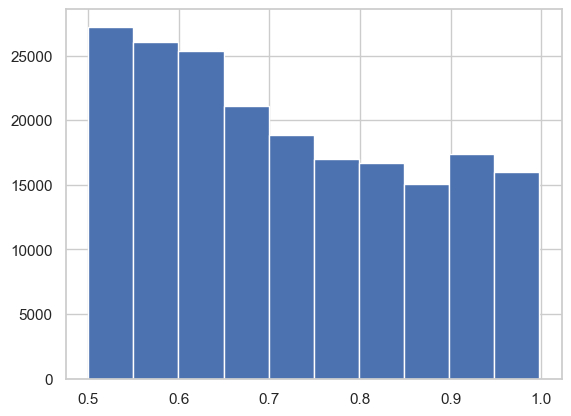

In [37]:
incorrect_with_high_probability_fp["predicted_prob"].hist()

In [38]:
#  take the high prob of fp

incorrect_with_high_probability_fp_high_prob = incorrect_with_high_probability_fp[incorrect_with_high_probability_fp["predicted_prob"]>0.7]

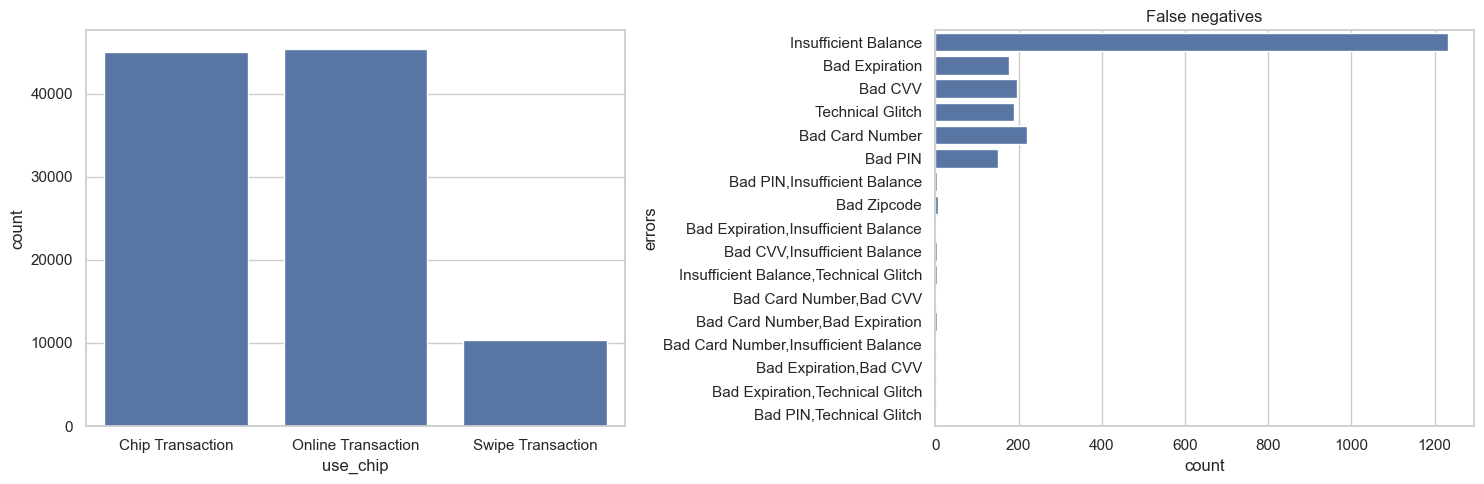

In [39]:
fig, axes = plt.subplots(1,2, figsize=(15,5))
plt.title("False negatives")

sns.countplot(data=incorrect_with_high_probability_fp_high_prob, x = "use_chip", ax = axes[0])
sns.countplot(data=incorrect_with_high_probability_fp_high_prob, y = "errors", ax = axes[1])
plt.tight_layout()


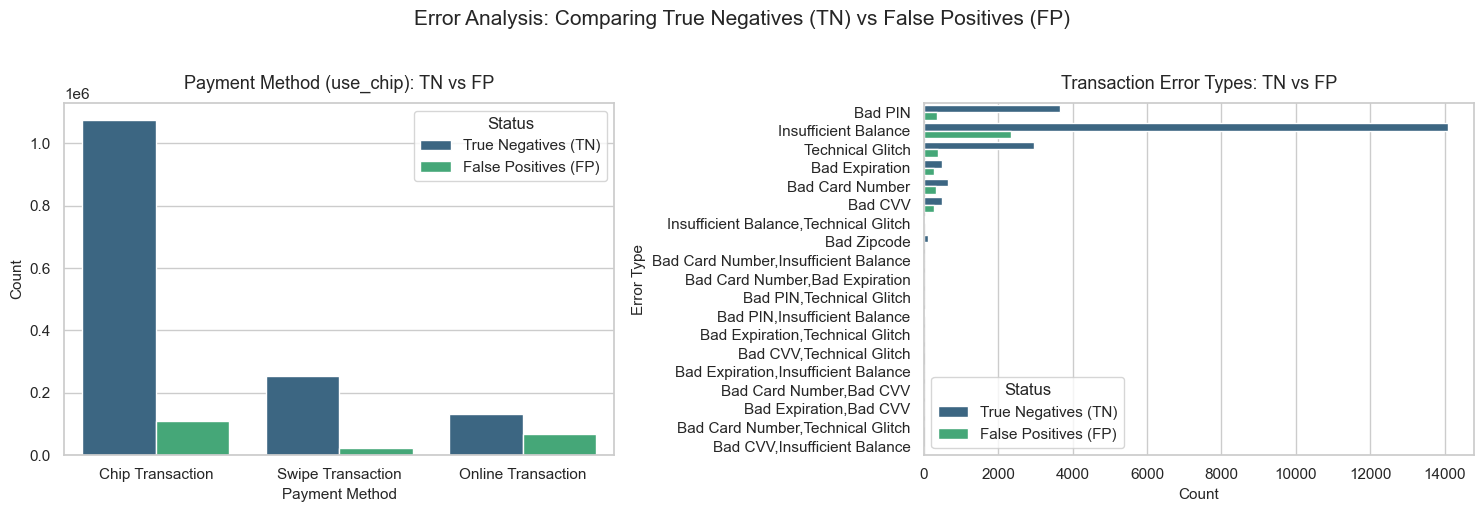

In [40]:
tn_df = correct_classified_tn.copy()
tn_df["Classification"] = "True Negatives (TN)"

fp_df = incorrect_with_high_probability_fp.copy()
fp_df["Classification"] = "False Positives (FP)"

df_compare = pd.concat([tn_df, fp_df], ignore_index=True)

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df_compare, x="use_chip", hue="Classification", ax=axes[0], palette="viridis")
axes[0].set_title("Payment Method (use_chip): TN vs FP", fontsize=13, pad=10)
axes[0].set_xlabel("Payment Method", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].legend(title="Status")

sns.countplot(data=df_compare, y="errors", hue="Classification", ax=axes[1], palette="viridis")
axes[1].set_title("Transaction Error Types: TN vs FP", fontsize=13, pad=10)
axes[1].set_xlabel("Count", fontsize=11)
axes[1].set_ylabel("Error Type", fontsize=11)
axes[1].legend(title="Status")

plt.suptitle("Error Analysis: Comparing True Negatives (TN) vs False Positives (FP)", fontsize=15, y=1.02)

plt.tight_layout()
plt.show()

looks like online transactions mislead the model

/var/folders/pk/2fr01p2d42j3b32375zb10ww0000gn/T/ipykernel_4521/1586515095.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=online_trxs, x="prediction_status", order=["True Negative (TN)", "False Positive (FP)", "True Positive (TP)", "False Negative (FN)"],palette="viridis", ax=axes[0, 0])
/var/folders/pk/2fr01p2d42j3b32375zb10ww0000gn/T/ipykernel_4521/1586515095.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=online_trxs,x="prediction_status",y="amount",order=["True Negative (TN)", "False Positive (FP)", "True Positive (TP)", "False Negative (FN)"],palette="viridis",ax=axes[0, 1])


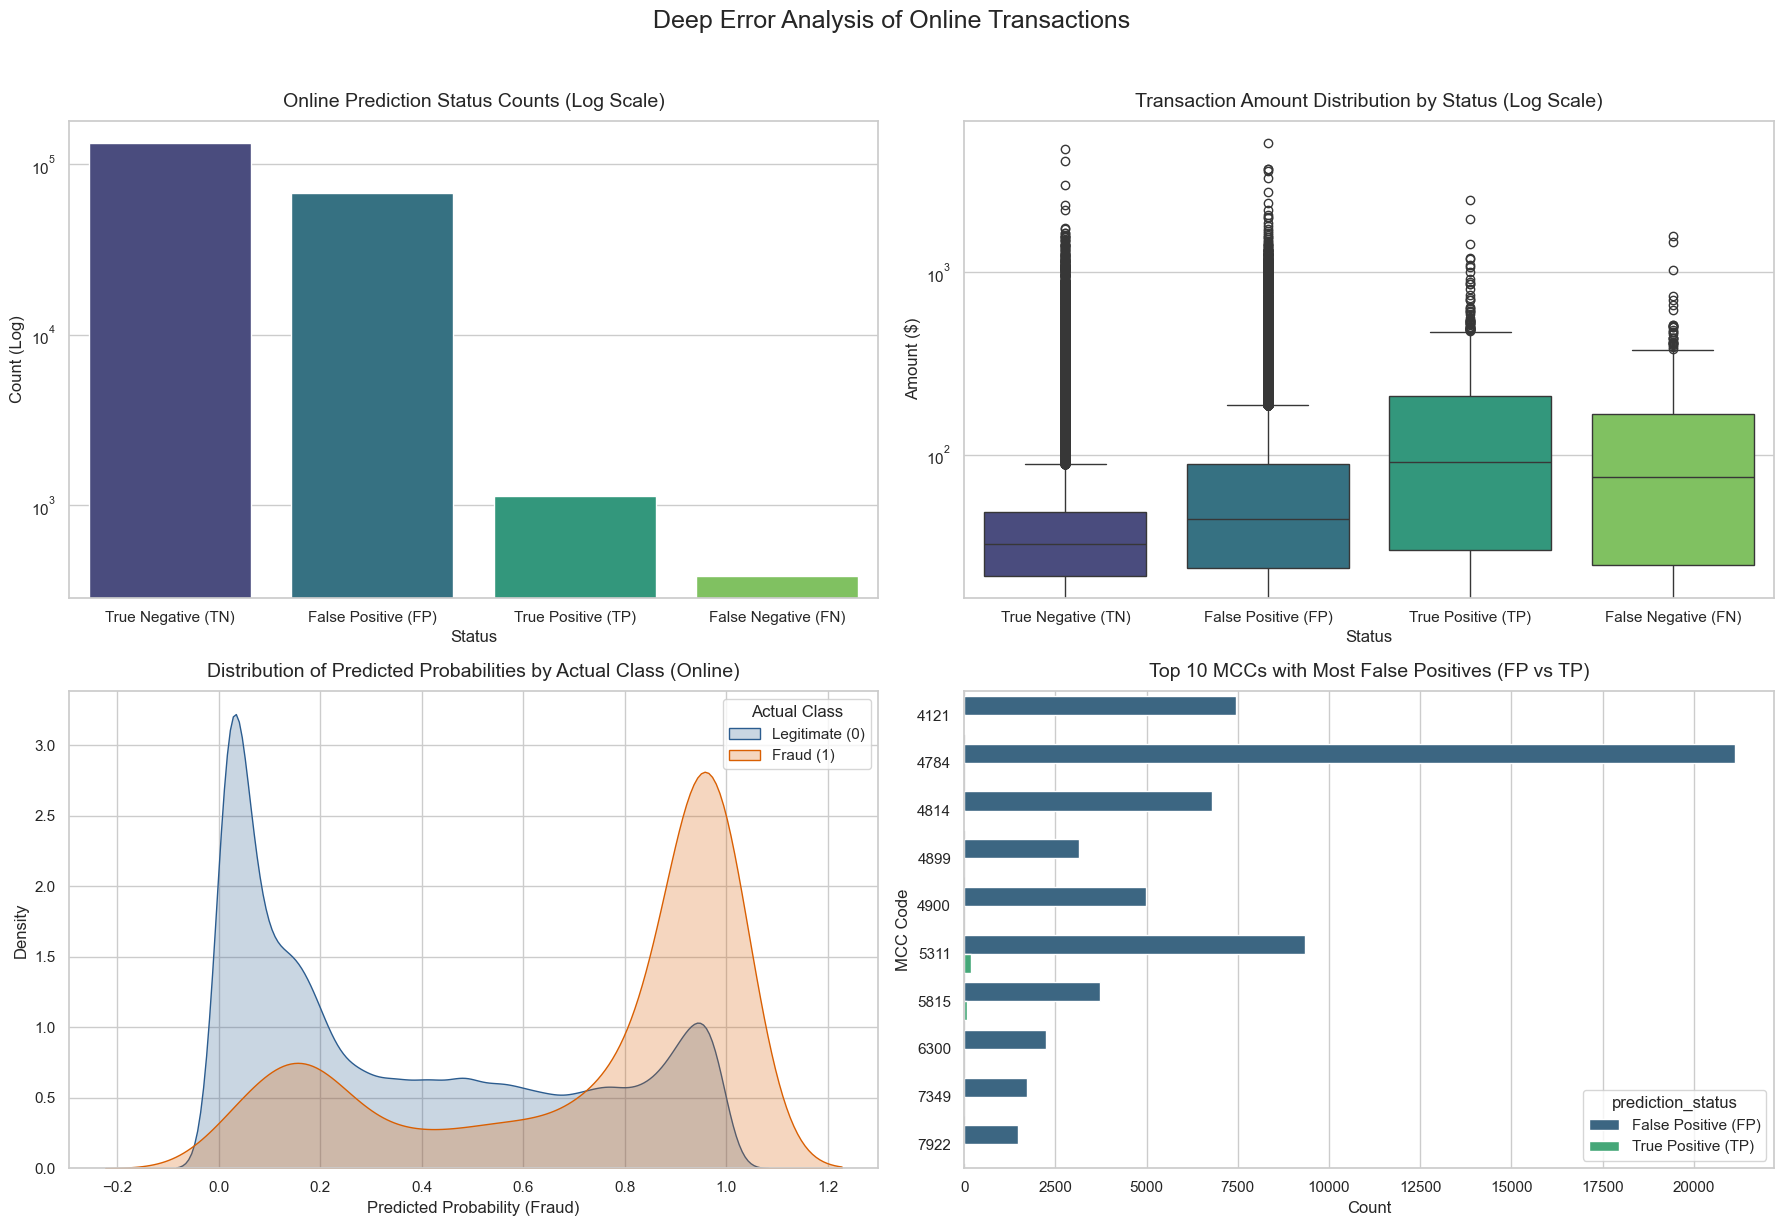

In [41]:
online_trxs = df[df["merchant_city"]=="ONLINE"].copy()

online_trxs["date"] = pd.to_datetime(online_trxs["date"])
online_trxs["hour"] = online_trxs["date"].dt.hour

conditions = [(online_trxs["target"] == "No") & (online_trxs["predicted_class"] == "No"),(online_trxs["target"] == "No") & (online_trxs["predicted_class"] == "Yes"),(online_trxs["target"] == "Yes") & (online_trxs["predicted_class"] == "Yes"),(online_trxs["target"] == "Yes") & (online_trxs["predicted_class"] == "No")]
choices = ["True Negative (TN)", "False Positive (FP)", "True Positive (TP)", "False Negative (FN)"]
online_trxs["prediction_status"] = np.select(conditions, choices, default="Unknown")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))


sns.countplot(data=online_trxs, x="prediction_status", order=["True Negative (TN)", "False Positive (FP)", "True Positive (TP)", "False Negative (FN)"],palette="viridis", ax=axes[0, 0])
axes[0, 0].set_yscale("log") 
axes[0, 0].set_title("Online Prediction Status Counts (Log Scale)", fontsize=14, pad=10)
axes[0, 0].set_xlabel("Status", fontsize=12)
axes[0, 0].set_ylabel("Count (Log)", fontsize=12)

sns.boxplot(data=online_trxs,x="prediction_status",y="amount",order=["True Negative (TN)", "False Positive (FP)", "True Positive (TP)", "False Negative (FN)"],palette="viridis",ax=axes[0, 1])
axes[0, 1].set_yscale("log")
axes[0, 1].set_title("Transaction Amount Distribution by Status (Log Scale)", fontsize=14, pad=10)
axes[0, 1].set_xlabel("Status", fontsize=12)
axes[0, 1].set_ylabel("Amount ($)", fontsize=12)


legit_probs = online_trxs[online_trxs["target"] == "No"]["predicted_prob"].dropna()
fraud_probs = online_trxs[online_trxs["target"] == "Yes"]["predicted_prob"].dropna()

if len(legit_probs) > 1:
    sns.kdeplot(x=legit_probs, fill=True, color="#2b5c8f", label="Legitimate (0)", ax=axes[1, 0])
if len(fraud_probs) > 1:
    sns.kdeplot(x=fraud_probs, fill=True, color="#d95f02", label="Fraud (1)", ax=axes[1, 0])

axes[1, 0].legend(title="Actual Class")
axes[1, 0].set_title("Distribution of Predicted Probabilities by Actual Class (Online)", fontsize=14, pad=10)
axes[1, 0].set_xlabel("Predicted Probability (Fraud)", fontsize=12)
axes[1, 0].set_ylabel("Density", fontsize=12)


top_fp_mccs = online_trxs[online_trxs["prediction_status"] == "False Positive (FP)"]["mcc"].value_counts().head(10).index
mcc_compare_df = online_trxs[online_trxs["mcc"].isin(top_fp_mccs)]

sns.countplot(data=mcc_compare_df,y="mcc",hue="prediction_status",hue_order=["False Positive (FP)", "True Positive (TP)"],palette="viridis",ax=axes[1, 1])
axes[1, 1].set_title("Top 10 MCCs with Most False Positives (FP vs TP)", fontsize=14, pad=10)
axes[1, 1].set_xlabel("Count", fontsize=12)
axes[1, 1].set_ylabel("MCC Code", fontsize=12)

plt.suptitle("Deep Error Analysis of Online Transactions", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

online transactions and mcc codes produce the highest damage

# Explore FN

In [42]:
incorrect_with_high_probability_fn

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,target,predicted_prob,predicted_class
335447,17548184,2016-03-22 11:26:00,1492,2615,150.55,Online Transaction,18215,ONLINE,NaN,NaN,5719,NaN,Yes,0.093698,No
336201,17549584,2016-03-22 15:42:00,1060,4291,318.39,Online Transaction,94123,ONLINE,NaN,NaN,5310,NaN,Yes,0.038844,No
341642,17559515,2016-03-24 17:04:00,1079,2842,74.23,Chip Transaction,53893,Jamaica,NY,11433.0,5300,NaN,Yes,0.053437,No
341645,17559526,2016-03-24 17:09:00,1079,2842,43.17,Online Transaction,60569,ONLINE,NaN,NaN,5300,NaN,Yes,0.081172,No
354560,17583328,2016-03-29 21:44:00,275,63,79.51,Online Transaction,76639,ONLINE,NaN,NaN,5732,NaN,Yes,0.006486,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989036,20584850,2017-12-27 16:23:00,1076,3858,23.21,Chip Transaction,86410,Rome,Italy,NaN,5211,NaN,Yes,0.038998,No
1989319,20585382,2017-12-27 19:18:00,1284,6066,8.36,Chip Transaction,22204,Rome,Italy,NaN,5541,NaN,Yes,0.013695,No
1991967,20590115,2017-12-28 19:25:00,408,2515,8.46,Chip Transaction,83018,Rome,Italy,NaN,5310,NaN,Yes,0.020455,No
1992007,20590190,2017-12-28 19:53:00,1076,3858,52.73,Chip Transaction,48919,Rome,Italy,NaN,5311,NaN,Yes,0.026190,No


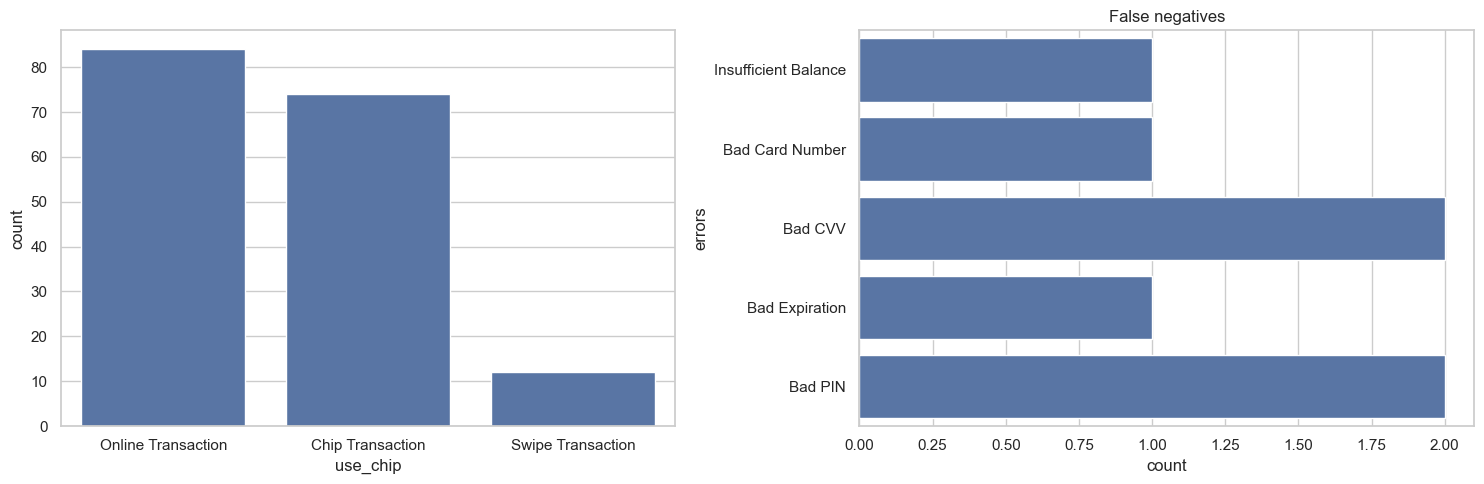

In [43]:
fig, axes = plt.subplots(1,2, figsize=(15,5))
plt.title("False negatives")

sns.countplot(data=incorrect_with_high_probability_fn, x = "use_chip", ax = axes[0])
sns.countplot(data=incorrect_with_high_probability_fn, y = "errors", ax = axes[1])
plt.tight_layout()


we fail on online transactions